# Preparación del Entorno

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Carga de Datos

In [3]:
df = pd.read_csv("titanic.csv")

# Definición de objetivos
1. ¿Existe una diferencia significativa en la tasa de supervivencia entre pasajeros de primera, segunda y tercera clase?
2. ¿Los pasajeros más jóvenes tuvieron mayor probabilidad de sobrevivir que los adultos y adultos mayores?
3. ¿Los pasajeros que viajaban solos y pagaron tarifas más bajas tuvieron menor probabilidad de sobrevivir que quienes viajaban acompañados y pagaron tarifas más altas?

# Preparación de datos (Data Cleaning)

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [7]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object


In [9]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [10]:
if 'age' in df.columns:
    df['age'] = df['age'].fillna(df['age'].mean())

if 'embarked' in df.columns:
    df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
if 'embark_town' in df.columns:
    df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

print("Missing values after imputation:")
display(df.isnull().sum())

Missing values after imputation:


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [11]:
df = df.drop(columns=['deck'], errors='ignore')

print("DataFrame después de eliminar la columna 'deck':")
display(df.head())

DataFrame después de eliminar la columna 'deck':


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


### Eliminación de Columnas Redundantes y Codificación de Variables Categóricas

# Eliminación de Columnas Deck, Sex y Alive.
Deck se elimina debido a que tenía un número muy alto de valores faltantes. En cuanto a Sex, ya tenemos las columnas Who y Adult_male que contienen información similar y detallada sobre el género. Asimismo, la columna Alive es redundante porque la columna Survived ya nos indica si el pasajero sobrevivió o no. Utilizamos 1 para sí, y 0 si no sobrevivió.

In [13]:
df = df.drop(columns=['sex', 'deck', 'alive'], errors='ignore')

print("DataFrame después de eliminar 'sex', 'deck' y 'alive':")
display(df.head())
print("Tipos de datos después de la eliminación de columnas:")
display(df.dtypes)

DataFrame después de eliminar 'sex', 'deck' y 'alive':


,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,22.0,1,0,7.2500,S,Third,man,True,Southampton,False
1,1,1,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,False
2,1,3,26.0,0,0,7.9250,S,Third,woman,False,Southampton,True
3,1,1,35.0,1,0,53.1000,S,First,woman,False,Southampton,False
4,0,3,35.0,0,0,8.0500,S,Third,man,True,Southampton,True


Tipos de datos después de la eliminación de columnas:


,0
survived,int64
pclass,int64
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object
adult_male,bool


In [12]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


# Estandarización de fechas, categorías y unidades
Se estandarizan las columnas de Age y Fare para una mejor visualización de los datos.

In [17]:
df['age'] = df['age'].astype(int)
df['fare'] = df['fare'].round(1)

print("DataFrame después de ajustar 'age' y 'fare':")
display(df.head())
print("Tipos de datos después de los ajustes:")
display(df.dtypes)

DataFrame después de ajustar 'age' y 'fare':


,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,22,1,0,7.2,S,Third,man,True,Southampton,False
1,1,1,38,1,0,71.3,C,First,woman,False,Cherbourg,False
2,1,3,26,0,0,7.9,S,Third,woman,False,Southampton,True
3,1,1,35,1,0,53.1,S,First,woman,False,Southampton,False
4,0,3,35,0,0,8.0,S,Third,man,True,Southampton,True


Tipos de datos después de los ajustes:


,0
survived,int64
pclass,int64
age,int64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,object
who,object
adult_male,bool


In [18]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

# Data Set limpio

In [19]:
display(df)

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,22,1,0,7.2,S,Third,man,True,Southampton,False
1,1,1,38,1,0,71.3,C,First,woman,False,Cherbourg,False
2,1,3,26,0,0,7.9,S,Third,woman,False,Southampton,True
3,1,1,35,1,0,53.1,S,First,woman,False,Southampton,False
4,0,3,35,0,0,8.0,S,Third,man,True,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,39,0,5,29.1,Q,Third,woman,False,Queenstown,False
887,1,1,19,0,0,30.0,S,First,woman,False,Southampton,True
888,0,3,29,1,2,23.4,S,Third,woman,False,Southampton,False
889,1,1,26,0,0,30.0,C,First,man,True,Cherbourg,True


In [20]:
df_cleaned = df.copy()
display (df_cleaned)

,survived,pclass,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,0,3,22,1,0,7.2,S,Third,man,True,Southampton,False
1,1,1,38,1,0,71.3,C,First,woman,False,Cherbourg,False
2,1,3,26,0,0,7.9,S,Third,woman,False,Southampton,True
3,1,1,35,1,0,53.1,S,First,woman,False,Southampton,False
4,0,3,35,0,0,8.0,S,Third,man,True,Southampton,True
...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,39,0,5,29.1,Q,Third,woman,False,Queenstown,False
887,1,1,19,0,0,30.0,S,First,woman,False,Southampton,True
888,0,3,29,1,2,23.4,S,Third,woman,False,Southampton,False
889,1,1,26,0,0,30.0,C,First,man,True,Cherbourg,True


# Análisis de Datos (EDA)


### Objetivo 1: ¿Existe una diferencia significativa en la tasa de supervivencia entre pasajeros de primera, segunda y tercera clase?

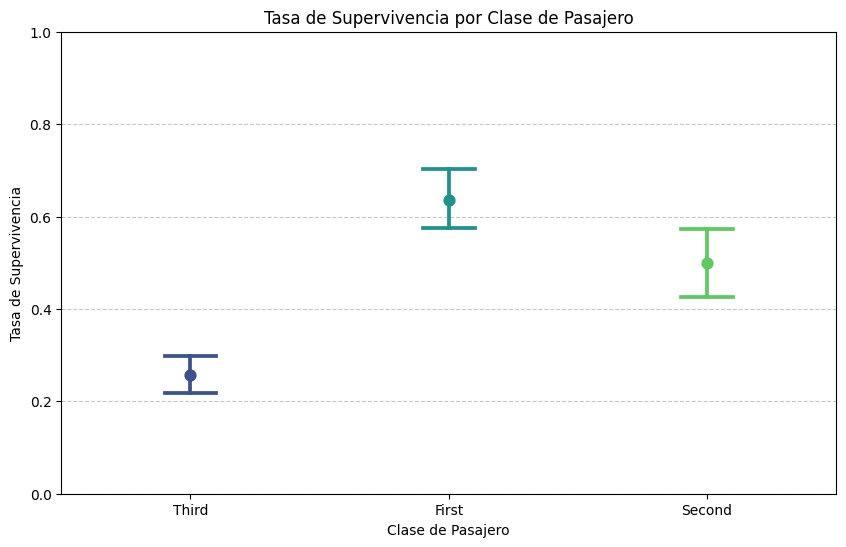

In [21]:
plt.figure(figsize=(10, 6))
sns.pointplot(x='class', y='survived', data=df_cleaned, palette='viridis', capsize=.2, hue='class', legend=False)
plt.title('Tasa de Supervivencia por Clase de Pasajero')
plt.xlabel('Clase de Pasajero')
plt.ylabel('Tasa de Supervivencia')
plt.ylim(0, 1) # Aseguramos que el eje Y vaya de 0 a 1 para tasas
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Objetivo 2: ¿Los pasajeros más jóvenes tuvieron mayor probabilidad de sobrevivir que los adultos y adultos mayores?

In [25]:
def age_group(age):
    if age <= 12:
        return 'Niño'
    elif age <= 25:
        return 'Joven'
    elif age <= 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

df_cleaned['age_group'] = df_cleaned['age'].apply(age_group)

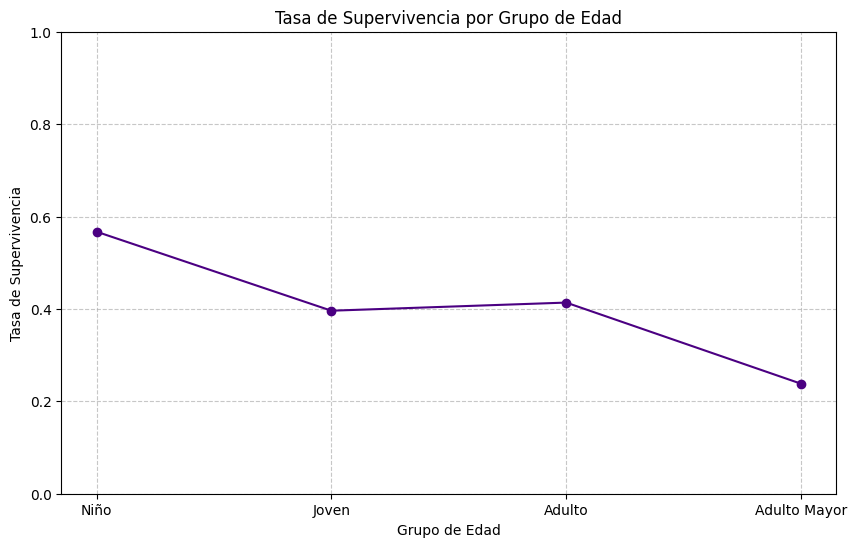

In [26]:
plt.figure(figsize=(10, 6))
survival_rate_by_age_group = df_cleaned.groupby('age_group')['survived'].mean().reindex(['Niño', 'Joven', 'Adulto', 'Adulto Mayor'])

plt.plot(survival_rate_by_age_group.index, survival_rate_by_age_group.values, marker='o', linestyle='-', color='indigo')
plt.title('Tasa de Supervivencia por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tasa de Supervivencia')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Objetivo 3: ¿Los pasajeros que viajaban solos y pagaron tarifas más bajas tuvieron menor probabilidad de sobrevivir que quienes viajaban acompañados y pagaron tarifas más altas?

In [29]:
import plotly.express as px

# Agrupar por 'alone' y 'class' y calcular la tasa de supervivencia y el conteo de pasajeros
df_treemap = df_cleaned.groupby(['alone', 'class']).agg(
    survived_rate=('survived', 'mean'),
    passenger_count=('survived', 'count')
).reset_index()

# Crear una columna de texto para la visualización del treemap
df_treemap['alone_text'] = df_treemap['alone'].map({True: 'Viaja Solo', False: 'Viaja Acompañado'})
df_treemap['class_text'] = df_treemap['class']

# Crear el treemap
fig = px.treemap(
    df_treemap,
    path=[px.Constant('Todos los Pasajeros'), 'alone_text', 'class_text'],
    values='passenger_count', # El tamaño de los cuadros representa el número de pasajeros
    color='survived_rate',    # El color representa la tasa de supervivencia
    color_continuous_scale='Viridis', # Escala de color
    color_continuous_midpoint=df_treemap['survived_rate'].mean(), # Punto medio para la escala de color
    title='Tasa de Supervivencia por Tipo de Viaje y Clase de Pasajero',
    labels={'alone_text': 'Tipo de Viaje', 'class_text': 'Clase de Pasajero', 'survived_rate': 'Tasa de Supervivencia', 'passenger_count': 'Conteo de Pasajeros'}
)

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

# Conclusión (Interpretación de los gráficos)

De acuerdo a los datos obtenidos con relación a los objetivos planteados al inicio del trabajo se observa que la tasa de supervivencia difiere significativamente, ya que los que viajaban en primera clase tuvieron una mayor tasa de supervivencia, que quienes lo hicieron en segunda y tercera clase. Asimismo, los pasajeros más jóvenes tuvieron mayores probabilidad de sobrevivir que los adultos y adultos mayores. Por último, quienes viajaron acompañados pagando tarifas altas tuvieron la mayor tasa de supervivencia.
